# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[Julia Belén Carrillo]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [1]:
! pip install requests beautifulsoup4 html5lib

In [8]:
import requests
from bs4 import BeautifulSoup

url = 'https://www.pudh.unam.mx/perseo/discurso-de-emma-watson-como-embajadora-de-buena-voluntad-de-onu-mujeres-en-la-inauguracion-de-la-campana-heforshe/'

headers = {
    "User-Agent": "Mozilla/5.0 (educational web scraping)"
}

respuesta = requests.get(url, headers=headers)
respuesta.raise_for_status()
print("Página descargada correctamente")


Página descargada correctamente


In [10]:
#Analizamos el contenido HTML de la pág
sopa = BeautifulSoup(respuesta.text, 'html.parser')

En esta primera parte me guié con los códigos vistos en clase.

Hasta aca lo que hice fue primero instalar las bibliotecas de Python que vamos a utilizar, e importarlas.
La libreria `request` me permite hacer la solicitud a la página web, y `BeautifulSoup` la usaré para analizar el contenido HTML y extraer el texto que me interesa.

Luego, guardo en la variable url la dirección de la página web que contiene el discurso con el que estoy trabajando.

Defino `User-Agent` dentro de `headers`para indircarle al sitio web desde donde se está realizando la solicitud. Esto se envía junto con la petición mediante `request.get()`.

El contenido obtenido lo almaceno dentro de la variable `respuesta`. A continuación uso `raise_for_status()` para comprobar que la solicitud se haya realizado correctamente, y me lo imprime. De no ser así, me devuelve un código de error.

Finalmente, utilizo `BeautifulSoup`para interpretar y organizar el código HTML obtenido de la página, y lo guardo en la variable `sopa`.


In [13]:
# prompt : buscar los parrafos que contiene una pagina web utilizando BeautifulSoup
parrafos = sopa.find_all('p')
texto_completo = ''
for p in parrafos:
    texto_completo += p.get_text(separator=' ', strip=True) + '\n\n'

print(texto_completo)


Hoy estamos lanzando una campaña llamada HeForShe (ÉlPorElla). Me dirijo a ustedes porque necesitamos de su ayuda. Queremos terminar con la inequidad de género y, para hacerlo, necesitamos que todos se involucren. Esta es la primera campaña en su tipo en las Naciones Unidas. Queremos tratar de movilizar a cuantos hombres y niños podamos para que sean agentes de cambio, y no sólo hablar de ello. Queremos tratar de asegurarnos de que sea algo tangible.

Fui designada como Embajadora de Buena Voluntad de ONU Mujeres hace seis meses, y mientras más hablé sobre feminismo, más me di cuenta de que luchar por los derechos de las mujeres muy a menudo es sinónimo de odio hacia los hombres. Si hay algo de lo que estoy segura, es de que esto debe terminar.



Es conveniente recordar que el feminismo, por definición, es la creencia de que los hombres y las mujeres deberían tener iguales derechos y oportunidades. Es la teoría de la equidad política, económica y social de los sexos. Yo comencé a cues

Bueno, acá generé el código con Gemini y luego investigué qué hace cada línea.

Mediante `find_all('p')`, se buscan todas las etiquetas `<p>`presentes en la página, ya que éstas representan los párrafos del contenido. Y a éstos se guardaron en la variable `parrafos`.
Se crea la variable `texto_completo` vacía, para que en ella se vayan guardando los párrafos extraídos.

El ciclo `for` recorre uno por uno los párrafos encontrados, y con `get_text()` me quedo solamente con el texto de cada párrafo, eliminando las etiquetas HTML.

`strip=True` lo que hace es eliminar espacios innecesarios al principio y al final. Y `separator=' '` agrega un espacio cuando existen distintos elementos del mismo párrafo.

Finalmente se imprime en pantalla todo el texto extraído de la página web.

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [14]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

#Obtenemos las stopwords en español
stopwords_es = set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Acá me guié con los codigos vistos en clase.

Importamos la librería `nltk` y de ella se importa `stopwords` que contiene la listas de palabras que queremos detectar que aparecen en nuestro texto y mostrarlas, y la descargamos.
Seleccionamos específicamente las `stopwords` del idioma español.

`set()` convierte esa lista en un conjunto y lo guardamos en la variable `stopword_es`

In [16]:
#prompt : mostrar las stopwords que aparecen en el texto extraído
palabras = texto_completo.lower().split()

stopwords_en_texto = []

for palabra in palabras:
    if palabra in stopwords_es:
        stopwords_en_texto.append(palabra)

print(stopwords_en_texto)

['estamos', 'una', 'me', 'a', 'porque', 'de', 'su', 'con', 'la', 'de', 'para', 'que', 'todos', 'se', 'esta', 'es', 'la', 'en', 'su', 'en', 'las', 'de', 'a', 'y', 'para', 'que', 'sean', 'de', 'y', 'no', 'de', 'de', 'de', 'que', 'sea', 'algo', 'fui', 'como', 'de', 'de', 'y', 'más', 'sobre', 'más', 'me', 'de', 'que', 'por', 'los', 'de', 'las', 'muy', 'a', 'es', 'de', 'los', 'hay', 'algo', 'de', 'lo', 'que', 'estoy', 'es', 'de', 'que', 'esto', 'es', 'que', 'el', 'por', 'es', 'la', 'de', 'que', 'los', 'y', 'las', 'y', 'es', 'la', 'de', 'la', 'y', 'de', 'los', 'yo', 'a', 'las', 'en', 'el', 'mucho', 'a', 'los', 'me', 'que', 'me', 'porque', 'las', 'de', 'que', 'para', 'nuestros', 'pero', 'a', 'los', 'a', 'los', 'a', 'por', 'de', 'la', 'a', 'los', 'mis', 'a', 'de', 'sus', 'porque', 'no', 'y', 'a', 'los', 'mis', 'eran', 'de', 'sus', 'que', 'yo', 'era', 'y', 'esto', 'no', 'me', 'pero', 'mi', 'me', 'que', 'el', 'se', 'ha', 'una', 'las', 'están', 'no', 'como', 'me', 'entre', 'son', 'como', 'muy', '

En este código tambien me ayudé generando el código con IA, pero al ser simple entendí lo que hace en cada paso, excepto lo que hace `split()` que a eso lo tuve que investigar:

Primero toma el contenido de `texto_completo` y lo transforma a minúsculas con `lower()` , y mediante `split()` divide el texto en palabras individuales. Y el resultado de esto lo guarda en la variable `palabras`.

Crea una lista vacia donde luego se irán almacenando todas las stopwords que coincida que aparecen en nuestro texto.

Mediante el ciclo `for` recorre cada palabra una por una dentro de la variable `palabras`, si esa palabra coincide con las `stopwords_es`, entonces la agrega al final de la lista `stopwords_en_texto`.

Luego que termina de recorrer todo el ciclo, imprime en pantalla aquellas stopwords que estan en el discurso que elegimos analizar.

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

In [21]:
#Paso el texto a minusculas

texto_limpio = texto_completo.lower()

print(texto_limpio)

hoy estamos lanzando una campaña llamada heforshe (élporella). me dirijo a ustedes porque necesitamos de su ayuda. queremos terminar con la inequidad de género y, para hacerlo, necesitamos que todos se involucren. esta es la primera campaña en su tipo en las naciones unidas. queremos tratar de movilizar a cuantos hombres y niños podamos para que sean agentes de cambio, y no sólo hablar de ello. queremos tratar de asegurarnos de que sea algo tangible.

fui designada como embajadora de buena voluntad de onu mujeres hace seis meses, y mientras más hablé sobre feminismo, más me di cuenta de que luchar por los derechos de las mujeres muy a menudo es sinónimo de odio hacia los hombres. si hay algo de lo que estoy segura, es de que esto debe terminar.



es conveniente recordar que el feminismo, por definición, es la creencia de que los hombres y las mujeres deberían tener iguales derechos y oportunidades. es la teoría de la equidad política, económica y social de los sexos. yo comencé a cues

In [22]:
#Elimino signos de puntuación

import string

texto_limpio = ''.join(c for c in texto_limpio if c not in string.punctuation)
print(texto_limpio)

hoy estamos lanzando una campaña llamada heforshe élporella me dirijo a ustedes porque necesitamos de su ayuda queremos terminar con la inequidad de género y para hacerlo necesitamos que todos se involucren esta es la primera campaña en su tipo en las naciones unidas queremos tratar de movilizar a cuantos hombres y niños podamos para que sean agentes de cambio y no sólo hablar de ello queremos tratar de asegurarnos de que sea algo tangible

fui designada como embajadora de buena voluntad de onu mujeres hace seis meses y mientras más hablé sobre feminismo más me di cuenta de que luchar por los derechos de las mujeres muy a menudo es sinónimo de odio hacia los hombres si hay algo de lo que estoy segura es de que esto debe terminar



es conveniente recordar que el feminismo por definición es la creencia de que los hombres y las mujeres deberían tener iguales derechos y oportunidades es la teoría de la equidad política económica y social de los sexos yo comencé a cuestionarme las conjetur

In [25]:
#Elimino caracteres extraños

import re

def quitar_caracteres(texto):
  return re.sub(r'[^\w\s]', '', texto)

texto_limpio = quitar_caracteres(texto_limpio)
print(texto_limpio)


hoy estamos lanzando una campaña llamada heforshe élporella me dirijo a ustedes porque necesitamos de su ayuda queremos terminar con la inequidad de género y para hacerlo necesitamos que todos se involucren esta es la primera campaña en su tipo en las naciones unidas queremos tratar de movilizar a cuantos hombres y niños podamos para que sean agentes de cambio y no sólo hablar de ello queremos tratar de asegurarnos de que sea algo tangible

fui designada como embajadora de buena voluntad de onu mujeres hace seis meses y mientras más hablé sobre feminismo más me di cuenta de que luchar por los derechos de las mujeres muy a menudo es sinónimo de odio hacia los hombres si hay algo de lo que estoy segura es de que esto debe terminar



es conveniente recordar que el feminismo por definición es la creencia de que los hombres y las mujeres deberían tener iguales derechos y oportunidades es la teoría de la equidad política económica y social de los sexos yo comencé a cuestionarme las conjetur

In [24]:
# Elimino las stopwords

#Primero separo el texto en palabras
palabras = texto_limpio.split()

filtradas = [p for p in palabras if p not in stopwords_es]

print(filtradas)

['hoy', 'lanzando', 'campaña', 'llamada', 'heforshe', 'élporella', 'dirijo', 'ustedes', 'necesitamos', 'ayuda', 'queremos', 'terminar', 'inequidad', 'género', 'hacerlo', 'necesitamos', 'involucren', 'primera', 'campaña', 'tipo', 'naciones', 'unidas', 'queremos', 'tratar', 'movilizar', 'cuantos', 'hombres', 'niños', 'podamos', 'agentes', 'cambio', 'sólo', 'hablar', 'ello', 'queremos', 'tratar', 'asegurarnos', 'tangible', 'designada', 'embajadora', 'buena', 'voluntad', 'onu', 'mujeres', 'hace', 'seis', 'meses', 'mientras', 'hablé', 'feminismo', 'di', 'cuenta', 'luchar', 'derechos', 'mujeres', 'menudo', 'sinónimo', 'odio', 'hacia', 'hombres', 'si', 'segura', 'debe', 'terminar', 'conveniente', 'recordar', 'feminismo', 'definición', 'creencia', 'hombres', 'mujeres', 'deberían', 'tener', 'iguales', 'derechos', 'oportunidades', 'teoría', 'equidad', 'política', 'económica', 'social', 'sexos', 'comencé', 'cuestionarme', 'conjeturas', 'basadas', 'género', 'hace', 'tiempo', '8', 'confundía', 'lla

Todo lo que hice hasta acá lo hice basándome en los aprendido en los apuntes de clase, sobre todo en el notebook "Limpieza de texto".

Para llegar a hacer la nube de palabras y detectar cuales son las que mas se repiten y cuales las que menos, debo pasalas a minúsculas, eliminar los caracteres extraños y los signos de puntuación, asi se las reconoce a todas las palabras por igual.

Luego, creo una lista llamada `filtradas` donde, a medida que recorro con un ciclo `for` todas las palabras en la variable `palabras`, se van almacenando aquellas que no se encuentren en `stopwords_es`.

In [27]:
#Nube de palabras

!pip install wordcloud

In [29]:
#prompt : unir las palabras en filtradas para convertir la lista en texto
texto_final = ' '.join(filtradas)

print(texto_final)

hoy lanzando campaña llamada heforshe élporella dirijo ustedes necesitamos ayuda queremos terminar inequidad género hacerlo necesitamos involucren primera campaña tipo naciones unidas queremos tratar movilizar cuantos hombres niños podamos agentes cambio sólo hablar ello queremos tratar asegurarnos tangible designada embajadora buena voluntad onu mujeres hace seis meses mientras hablé feminismo di cuenta luchar derechos mujeres menudo sinónimo odio hacia hombres si segura debe terminar conveniente recordar feminismo definición creencia hombres mujeres deberían tener iguales derechos oportunidades teoría equidad política económica social sexos comencé cuestionarme conjeturas basadas género hace tiempo 8 confundía llamaran mandona quería dirigir obras teatro montábamos padres niños 14 comencé ser sexualizada ciertos sectores prensa 15 mejores amigas comenzaron salirse amados equipos deportivos querían parecer machonas 18 amigos hombres incapaces expresar sentimientos decidí feminista par

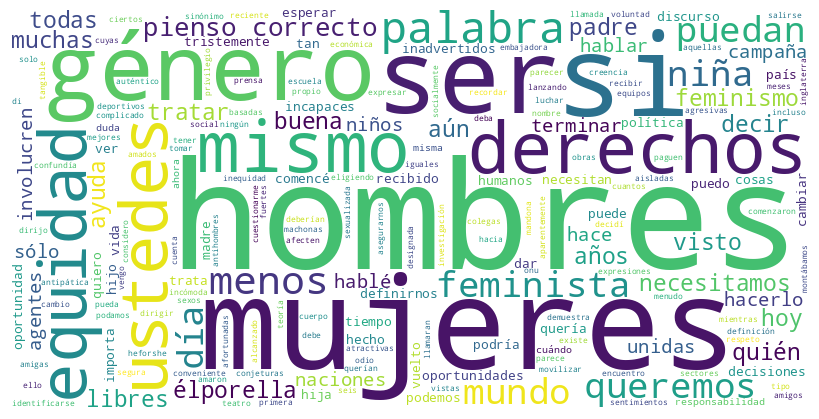

In [30]:
#Creo la nube de palabras

from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width = 800, height = 400,background_color = 'white').generate(texto_final)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

Al empezar a crear la nube de palabras guiándome con el anexo de wordcloud, me salió un error xq quise usar `generate(filtradas)`, ahí comprendí que `generate()` necesita recibir si o si un texto (`string`). Por eso generé el código con IA para pasar convertir la lista  `filtradas` a un texto

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [34]:
#prompt : Tomar el texto en texto_completo y descomponerlo en oraciones

import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [36]:
oraciones = sent_tokenize(texto_completo, language='spanish')

print(oraciones)

['Hoy estamos lanzando una campaña llamada HeForShe (ÉlPorElla).', 'Me dirijo a ustedes porque necesitamos de su ayuda.', 'Queremos terminar con la inequidad de género y, para hacerlo, necesitamos que todos se involucren.', 'Esta es la primera campaña en su tipo en las Naciones Unidas.', 'Queremos tratar de movilizar a cuantos hombres y niños podamos para que sean agentes de cambio, y no sólo hablar de ello.', 'Queremos tratar de asegurarnos de que sea algo tangible.', 'Fui designada como Embajadora de Buena Voluntad de ONU Mujeres hace seis meses, y mientras más hablé sobre feminismo, más me di cuenta de que luchar por los derechos de las mujeres muy a menudo es sinónimo de odio hacia los hombres.', 'Si hay algo de lo que estoy segura, es de que esto debe terminar.', 'Es conveniente recordar que el feminismo, por definición, es la creencia de que los hombres y las mujeres deberían tener iguales derechos y oportunidades.', 'Es la teoría de la equidad política, económica y social de los

Primero separamos el texto en oraciones, ya que si primero lo limpiamos y eliminamos los puntos, no podremos separar las oraciones.

`sent_tokenize` se encarga de dividir el texto en oraciones

In [54]:
#Ahora sí limpio cada oración
import re

oraciones_limpias = []

for oracion in oraciones:

  #Paso a minusculas
  oracion = oracion.lower()

  #prompt : Eliminar las URLs
  oracion = re.sub(r'https?://\S+|www\.\S+', '', oracion)

  #prompt: Eliminar los números
  oracion = re.sub(r'\d+', '', oracion)

  #Elimino signos de puntuación
  oracion = ''.join(c for c in oracion if c not in string.punctuation)

  #Elimino caracteres extraños
  def quitar_caracteres(oracion):
    return re.sub(r'[^\w\s]', '', oracion)

  oracion = quitar_caracteres(oracion)

  #Elimino las stopwords
  palabras = oracion.split()
  filtradas = [p for p in palabras if p not in stopwords_es]

  # Vuelvo a unir las palabras
  oracion = ' '.join(filtradas)

  # Agrego cada oración limpia a la lista
  oraciones_limpias.append(oracion)

print(oraciones_limpias)

['hoy lanzando campaña llamada heforshe élporella', 'dirijo ustedes necesitamos ayuda', 'queremos terminar inequidad género hacerlo necesitamos involucren', 'primera campaña tipo naciones unidas', 'queremos tratar movilizar cuantos hombres niños podamos agentes cambio sólo hablar ello', 'queremos tratar asegurarnos tangible', 'designada embajadora buena voluntad onu mujeres hace seis meses mientras hablé feminismo di cuenta luchar derechos mujeres menudo sinónimo odio hacia hombres', 'si segura debe terminar', 'conveniente recordar feminismo definición creencia hombres mujeres deberían tener iguales derechos oportunidades', 'teoría equidad política económica social sexos', 'comencé cuestionarme conjeturas basadas género hace tiempo', 'confundía llamaran mandona quería dirigir obras teatro montábamos padres', 'niños', 'comencé ser sexualizada ciertos sectores prensa mejores amigas comenzaron salirse amados equipos deportivos querían parecer machonas amigos hombres incapaces expresar sen

Creé una lista vacia llamada `oraciones_limpias` donde voy a ir almacenando todas las oraciones luego de limpiarlas.

Uso un ciclo for para recorrer todas las oraciones que están en `oraciones`, una por una las convierto a minúsculas, luego elimino los signos de puntuación y caracteres extraños, también elimino las URLs y los números que puedan aparecer en el texto ya que no son necesarios para el análisis que quiero realizar. Por último quito las stopwords, que ya anteriormente las habiamos cargado en español en `stopwords_es`. Para eliminarlas primero debo separar la oración en palabras, recorrer con otro ciclo for palabra por palabra en cada oración y comparar si pertenecen o no a `stopwords_es`, si no pertenece, la guardo en la lista `filtradas`. Como `filtradas` es una lista de palabras, utilizo `' '.join(filtradas)` para volver a unirlas y formar nuevamente una oración. Luego agrego esa oración ya limpia a la lista `oraciones_limpias`. El ciclo repite el mismo proceso con cada una de las oraciones.

Finalmente imprimimos en pantalla lo que nos quedó guardado en la lista `oraciones_limpias`

Tuve que investigar como eliminar una URL que me aparecía en el texto y también unos numeros que ví que aparecían al imprimir el vocabulario

In [60]:
# prompt: toma oraciones_limpias y crea la matriz documento-vocabulario

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

matriz = vectorizer.fit_transform(oraciones_limpias)

print("Vocabulario")
print(vectorizer.get_feature_names_out())

Vocabulario
['accidentes' 'acerca' 'actuales' 'adelante' 'afecten' 'afortunadas'
 'agentes' 'agresivas' 'agresivos' 'ahora' 'aisladas' 'alcanzado' 'algún'
 'amados' 'amaron' 'ambición' 'amigas' 'amigos' 'antihombres' 'antipática'
 'aparentemente' 'aprovechar' 'aquellas' 'asegurarnos' 'asesino'
 'asumieron' 'asunto' 'atractivas' 'atrapados' 'audiencia' 'auténtico'
 'ayuda' 'ayudar' 'años' 'aún' 'basadas' 'beijing' 'beneficios'
 'bienvenido' 'buena' 'buenos' 'burke' 'cambiando' 'cambiar' 'cambiarán'
 'cambio' 'campaña' 'casarán' 'casi' 'chica' 'ciertos' 'clinton' 'colegas'
 'comencé' 'comenzar' 'comenzaron' 'completa' 'complicado' 'confundía'
 'conjeturas' 'conjuntos' 'consecuencia' 'considero' 'constituye'
 'controladas' 'controlar' 'conveniente' 'conversación' 'coronaria'
 'correcto' 'cosas' 'creencia' 'crees' 'cuantos' 'cuenta' 'cuerpo'
 'cuestionarme' 'cursar' 'cuyas' 'cuándo' 'cáncer' 'cómo' 'dada' 'dar'
 'deba' 'debe' 'deberíamos' 'deberían' 'decidí' 'decir' 'decisiones'
 'definici

In [61]:
#Muestra la matriz documento-vocabulario
print("Matriz documento-vocabulario")
print(matriz.toarray())

Matriz documento-vocabulario
[[0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Primero importo `CountVectorizer` de la libreria `sklearn`, que me va a permitir tranformar las oraciones en una representación numérica.
Creo el objeto `vectorizer` utilizando `CountVectorizer()`.

`fit` identifica las palabras diferentes en `oraciones_limpias` y crea el vocabulario, `trasnform` crea la matriz documento-vocabulario, contando cuántas veces aparece cada palabra del vocabulario en cada oración. Y guardo el resultado en la variable `matriz`.

Con `print(vectorizer.get_feature_names_out())` imprimo en pantalla el vocabulario, es decir, los nombres de cada columna de la matriz.

Finalmente, `print(matriz.toarray())` me imprime en pantalla la matriz documento-vocabulario, en la cual, cada fila representa una oración, cada columna representa una palabra del vocabulario y los valores indican cuántas veces aparece cada palabra en la oración.


#### 2.3.2 Determina la longitud de tu vocabulario.

In [57]:
vocabulario = vectorizer.get_feature_names_out()

print(f"La longitud del vocabulario es: {len(vocabulario)}")

La longitud del vocabulario es: 382


Acá simplemente guardé el vocabulario que imprimimos antes en una variable `vocabulario`, y le aplique `len()` que devuelve la longitud del mismo.


#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(oraciones_limpias)

print("Vocabulario TF-IDF")
print(tfidf_vectorizer.get_feature_names_out())

print("\nMatriz TF-IDF")
print(tfidf_matrix.toarray())

Vocabulario TF-IDF
['accidentes' 'acerca' 'actuales' 'adelante' 'afecten' 'afortunadas'
 'agentes' 'agresivas' 'agresivos' 'ahora' 'aisladas' 'alcanzado' 'algún'
 'amados' 'amaron' 'ambición' 'amigas' 'amigos' 'antihombres' 'antipática'
 'aparentemente' 'aprovechar' 'aquellas' 'asegurarnos' 'asesino'
 'asumieron' 'asunto' 'atractivas' 'atrapados' 'audiencia' 'auténtico'
 'ayuda' 'ayudar' 'años' 'aún' 'basadas' 'beijing' 'beneficios'
 'bienvenido' 'buena' 'buenos' 'burke' 'cambiando' 'cambiar' 'cambiarán'
 'cambio' 'campaña' 'casarán' 'casi' 'chica' 'ciertos' 'clinton' 'colegas'
 'comencé' 'comenzar' 'comenzaron' 'completa' 'complicado' 'confundía'
 'conjeturas' 'conjuntos' 'consecuencia' 'considero' 'constituye'
 'controladas' 'controlar' 'conveniente' 'conversación' 'coronaria'
 'correcto' 'cosas' 'creencia' 'crees' 'cuantos' 'cuenta' 'cuerpo'
 'cuestionarme' 'cursar' 'cuyas' 'cuándo' 'cáncer' 'cómo' 'dada' 'dar'
 'deba' 'debe' 'deberíamos' 'deberían' 'decidí' 'decir' 'decisiones'
 'd

Importo `TfidVectorizer` de la librería `sklearn`, que trasnforma las oraciones en una representación numérica utilizando TF-IDF, que asigna un peso a cada palabra según su importancia dentro de cada oración.

Creo el objeto `tfidf_vectorizer`.

Tomo las oraciones en `oraciones_limpias`, con `fit` identifica las palabras diferentes y crea el vocabulario, mientras que `transform` calcula el valor TF-IDF de cada palabra para cada oración. Y el resultado se guarda en la variable `tfidf_matrix`.

Tal como hicimos antes, imprimo en pantalla el vocabulario y la matriz TF-IDF.

Cada fila representa una oración, cada columna una palabra del vocabulario y cada valor indica el peso o importancia de esa palabra en la oración.



Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

In [62]:
#Muestro los números de mi matriz

print("Cantidad de documentos:", tfidf_matrix.shape[0])
print("Tamaño del vocabulario:", tfidf_matrix.shape[1])
print("Tamaño de la matriz:", tfidf_matrix.shape)

Cantidad de documentos: 71
Tamaño del vocabulario: 381
Tamaño de la matriz: (71, 381)


La matriz obtenida esta formada por 71 documentos 381 palabras diferentes, su tamaño es (71, 381).

Conclusión de la matriz TF-IDF:
A partir de esta matriz pude representar numéricamente las oraciones del discurso y determinar la importancia que tiene cada palabra dentro de cada una de ellas. TF-IDF asigna un peso teniendo en cuenta tanto su presencia en una oración como su aparición en el resto de los documentos. De esta manera, las palabras que aparecen en muchas oraciones pierden relevancia, mientras que aquellas que son más características de determinadas oraciones obtienen un peso mayor. Esto permite analizar el texto de una manera más significativa.

# Conclusiones

A lo largo de este trabajo pude aplicar diferentes técnicas de procesamiento de lenguaje natural partiendo de un texto real obtenido de Internet. Primero realicé web scraping para extraer el discurso de Emma Watson y, a partir de ese texto, fui realizando distintas etapas de preprocesamiento, como convertir el contenido a minúsculas, eliminar signos de puntuación, caracteres extraños, URLs, números y stopwords.

Una vez limpio el texto, pude generar una nube de palabras para visualizar de manera sencilla cuáles tenían mayor presencia. Luego dividí el discurso en oraciones, considerando cada una de ellas como un documento, y construí una matriz documento-vocabulario para representar numéricamente la frecuencia de las palabras.

Finalmente, apliqué TF-IDF, lo que permitió ir más allá de la cantidad de veces que aparece una palabra y analizar su importancia dentro de cada documento en relación con el texto completo.

En conclusión, este trabajo me permitió comprender cómo un texto que inicialmente se encuentra en un formato no estructurado puede pasar por distintas etapas de limpieza y transformación hasta convertirse en información numérica que puede ser analizada. También pude ver la importancia del preprocesamiento, ya que la calidad de la limpieza influye directamente en los resultados obtenidos posteriormente.